In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler

In [12]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display first few rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Dataset shape: (569, 31)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave poi

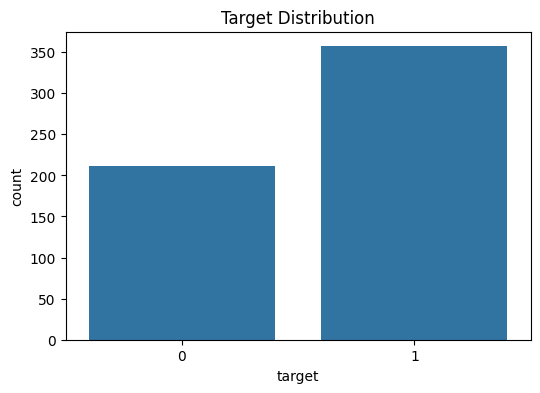

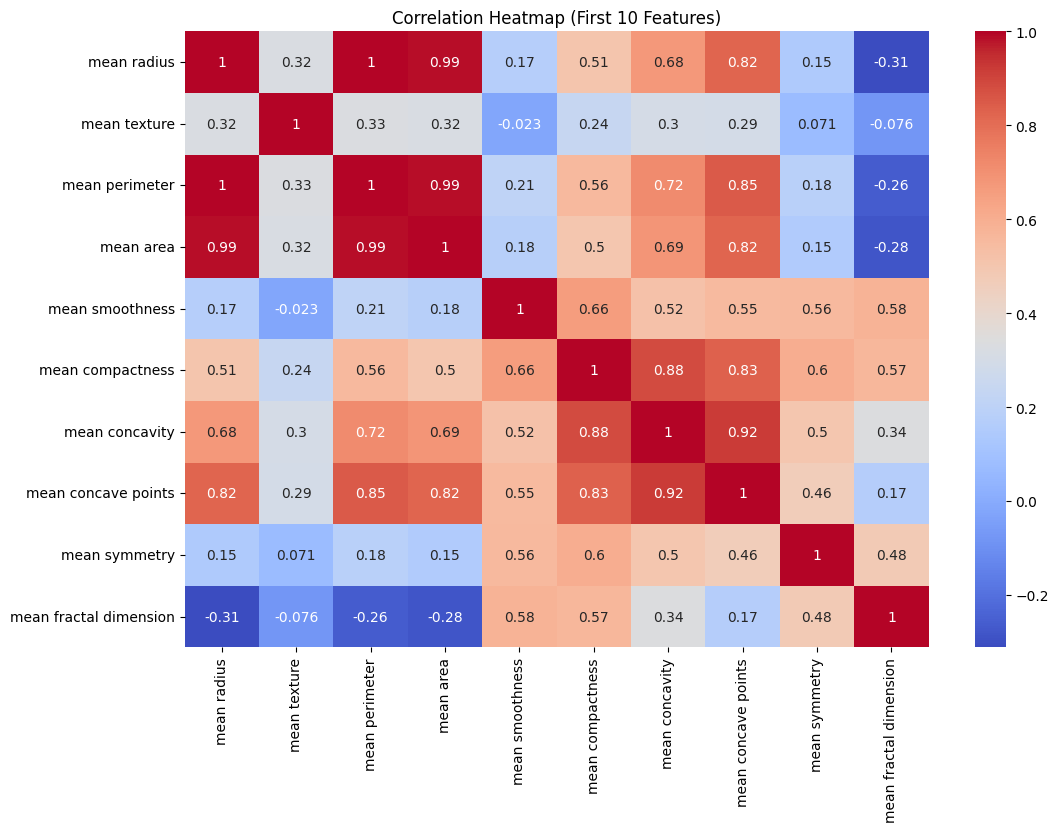

In [13]:
# Exploratory Data Analysis (EDA)

# Basic info
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Target distribution
print("\nTarget distribution:")
print(df['target'].value_counts())

# Visualize target distribution
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

# Correlation heatmap (first 10 features for readability)
plt.figure(figsize=(12,8))
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (First 10 Features)')
plt.show()

In [14]:
# Train-Test Split

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:", np.bincount(y_train))
print("Testing target distribution:", np.bincount(y_test))

Training set shape: (455, 30)
Testing set shape: (114, 30)
Training target distribution: [170 285]
Testing target distribution: [42 72]


In [15]:
# Choose Algorithm and Fit the Model

# Logistic Regression
model = LogisticRegression(random_state=42)

# Fit the model
model.fit(X_train, y_train)

print("Model coefficients:")
print(model.coef_)
print("\nModel intercept:")
print(model.intercept_)

Model coefficients:
[[-0.53124713 -0.54864155 -0.4944662  -0.54862896 -0.23805541  0.65501625
  -0.60855225 -0.71355886 -0.15805113  0.20000713 -1.123324    0.239566
  -0.59216781 -0.89903369 -0.1688095   0.62720617  0.17157712 -0.4505959
   0.35629158  0.43422032 -0.95633068 -1.23768781 -0.76796996 -0.93596362
  -0.71998668  0.07401684 -0.8233741  -0.94260922 -0.92523084 -0.19446886]]

Model intercept:
[0.16585603]


In [16]:
# Make Predictions

# Predict on test set
y_pred = model.predict(X_test)

# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred[:10])
print("\nFirst 10 actual values:")
print(y_test[:10].values)

First 10 predictions:
[0 1 0 1 0 1 1 0 0 0]

First 10 actual values:
[0 1 0 1 0 1 1 0 0 0]


In [17]:
# Model Evaluation

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
[[41  1]
 [ 1 71]]


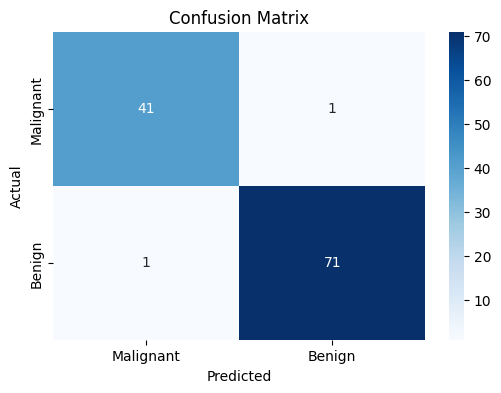

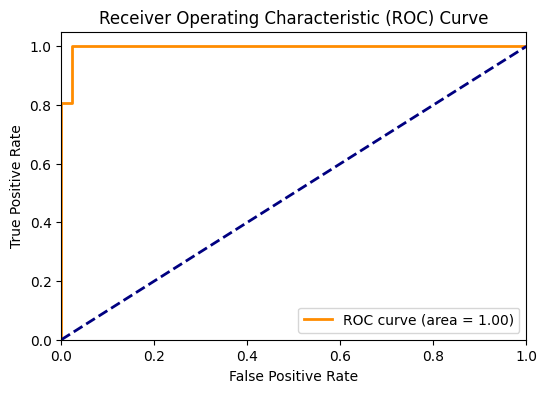

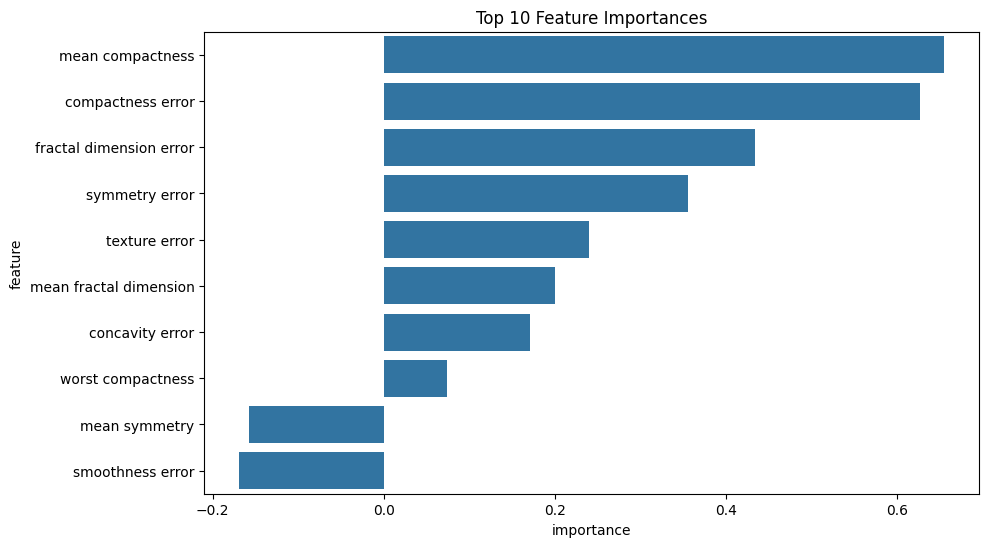

In [18]:
# Plotting

# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Feature Importance (coefficients)
feature_importance = pd.DataFrame({'feature': data.feature_names, 'importance': model.coef_[0]})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Feature Importances')
plt.show()

# Logistic Regression Example: Breast Cancer Classification

This notebook demonstrates a complete workflow for Logistic Regression on the Breast Cancer dataset, including EDA, train-test split, model training, evaluation, and visualization.